In [160]:
import pandas as pd

In [161]:
df = pd.read_csv('/Users/melanyalegre/Documents/International Business/4th year/Data Analytics/Data Science/DS_assignment_data - Copy (1).csv')
df.head()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,MOBILENO_AVL_FLAG,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,1441,01/01/1984,Salaried,03/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,1502,31/07/1985,Self employed,26/09/2018,1,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,1497,24/08/1985,Self employed,01/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,1501,30/12/1993,Self employed,26/10/2018,1,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,1495,09/12/1977,Self employed,26/09/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [162]:
df = df.drop(columns=['UNIQUEID', 'BRANCH_ID', 'CURRENT_PINCODE_ID','DISBURSAL_DATE','PERFORM_CNS_SCORE_DESCRIPTION'])

In [163]:
df.dtypes


DISBURSED_AMOUNT                         int64
ASSET_COST                               int64
LTV                                    float64
DATE_OF_BIRTH                           object
EMPLOYMENT_TYPE                         object
MOBILENO_AVL_FLAG                        int64
AADHAR_FLAG                              int64
PAN_FLAG                                 int64
VOTERID_FLAG                             int64
DRIVING_FLAG                             int64
PASSPORT_FLAG                            int64
PERFORM_CNS_SCORE                        int64
PRI_NO_OF_ACCTS                          int64
PRI_ACTIVE_ACCTS                         int64
PRI_OVERDUE_ACCTS                        int64
PRI_CURRENT_BALANCE                      int64
PRI_SANCTIONED_AMOUNT                    int64
PRI_DISBURSED_AMOUNT                     int64
SEC_NO_OF_ACCTS                          int64
SEC_ACTIVE_ACCTS                         int64
SEC_OVERDUE_ACCTS                        int64
SEC_CURRENT_B

In [164]:
df.isnull().sum()

DISBURSED_AMOUNT                         0
ASSET_COST                               0
LTV                                      0
DATE_OF_BIRTH                            0
EMPLOYMENT_TYPE                        144
MOBILENO_AVL_FLAG                        0
AADHAR_FLAG                              0
PAN_FLAG                                 0
VOTERID_FLAG                             0
DRIVING_FLAG                             0
PASSPORT_FLAG                            0
PERFORM_CNS_SCORE                        0
PRI_NO_OF_ACCTS                          0
PRI_ACTIVE_ACCTS                         0
PRI_OVERDUE_ACCTS                        0
PRI_CURRENT_BALANCE                      0
PRI_SANCTIONED_AMOUNT                    0
PRI_DISBURSED_AMOUNT                     0
SEC_NO_OF_ACCTS                          0
SEC_ACTIVE_ACCTS                         0
SEC_OVERDUE_ACCTS                        0
SEC_CURRENT_BALANCE                      0
SEC_SANCTIONED_AMOUNT                    0
SEC_DISBURS

In [165]:
df['EMPLOYMENT_TYPE'] = df['EMPLOYMENT_TYPE'].fillna('Unknown')

In [166]:
df = pd.get_dummies(df, columns=['EMPLOYMENT_TYPE'], dtype=int)

AI CODE

In [167]:
def convert_to_months(age_string):
    years = int(age_string.split('yrs')[0])
    months = int(age_string.split(' ')[1].replace('mon',''))
    return years*12 + months

In [168]:
df["AVERAGE_ACCT_AGE"] = df["AVERAGE_ACCT_AGE"].apply(convert_to_months)
df["CREDIT_HISTORY_LENGTH"] = df["CREDIT_HISTORY_LENGTH"].apply(convert_to_months)

In [169]:
df["DATE_OF_BIRTH"] = pd.to_datetime(df["DATE_OF_BIRTH"], dayfirst=True)
df["AGE"] = ((pd.Timestamp.today() - df["DATE_OF_BIRTH"]).dt.days / 365).round().astype(int)

In [170]:
df.dtypes


DISBURSED_AMOUNT                                int64
ASSET_COST                                      int64
LTV                                           float64
DATE_OF_BIRTH                          datetime64[ns]
MOBILENO_AVL_FLAG                               int64
AADHAR_FLAG                                     int64
PAN_FLAG                                        int64
VOTERID_FLAG                                    int64
DRIVING_FLAG                                    int64
PASSPORT_FLAG                                   int64
PERFORM_CNS_SCORE                               int64
PRI_NO_OF_ACCTS                                 int64
PRI_ACTIVE_ACCTS                                int64
PRI_OVERDUE_ACCTS                               int64
PRI_CURRENT_BALANCE                             int64
PRI_SANCTIONED_AMOUNT                           int64
PRI_DISBURSED_AMOUNT                            int64
SEC_NO_OF_ACCTS                                 int64
SEC_ACTIVE_ACCTS            

In [171]:
df.describe()

,DISBURSED_AMOUNT,ASSET_COST,LTV,DATE_OF_BIRTH,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,...,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT,EMPLOYMENT_TYPE_Salaried,EMPLOYMENT_TYPE_Self employed,EMPLOYMENT_TYPE_Unknown,AGE
count,5000.000000,5000.000000,5000.000000,5000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,52618.059800,75361.666000,72.859102,1983-12-12 04:53:45.600000,1.0,0.705400,0.097800,0.268400,0.030800,0.001600,...,0.314800,0.08860,8.602200,14.772000,0.19120,0.224400,0.451800,0.519400,0.028800,42.222200
min,13990.000000,39605.000000,17.050000,1954-08-13 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,26.000000
25%,46176.750000,65831.000000,66.837500,1977-01-01 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,34.000000
50%,52603.000000,70764.000000,74.850000,1985-11-13 12:00:00,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,40.000000
75%,58585.000000,78800.250000,80.610000,1992-03-05 00:00:00,1.0,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.00000,12.000000,21.000000,0.00000,0.000000,1.000000,1.000000,0.000000,49.000000
max,151143.000000,225100.000000,94.990000,2000-08-18 00:00:00,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,14.000000,5.00000,154.000000,296.000000,18.00000,1.000000,1.000000,1.000000,1.000000,72.000000
std,11356.022842,16511.840509,11.417345,NaN,0.0,0.455908,0.297074,0.443171,0.172793,0.039972,...,0.857816,0.35941,15.310272,26.939183,0.76887,0.417228,0.497721,0.499673,0.167261,9.861251


In [172]:
df.columns = df.columns.str.replace(" ", "_")

In [173]:
corr = df.corr()

corr["DISBURSED_AMOUNT"].sort_values(ascending=False)

DISBURSED_AMOUNT                       1.000000
ASSET_COST                             0.696747
LTV                                    0.438774
LOAN_DEFAULT                           0.105253
DATE_OF_BIRTH                          0.066182
EMPLOYMENT_TYPE_Unknown                0.065989
EMPLOYMENT_TYPE_Salaried               0.061016
VOTERID_FLAG                           0.056148
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.052429
PRI_NO_OF_ACCTS                        0.036486
NEW_ACCTS_IN_LAST_SIX_MONTHS           0.035209
PRI_OVERDUE_ACCTS                      0.029049
PRI_ACTIVE_ACCTS                       0.026774
PRI_CURRENT_BALANCE                    0.022317
NO_OF_INQUIRIES                        0.020236
PRI_DISBURSED_AMOUNT                   0.019303
PRI_SANCTIONED_AMOUNT                  0.019143
SEC_INSTAL_AMT                         0.011213
SEC_NO_OF_ACCTS                        0.010816
DRIVING_FLAG                           0.009953
SEC_ACTIVE_ACCTS                       0

In [174]:
import statsmodels.formula.api as sm
model_1 = sm.ols(
'DISBURSED_AMOUNT ~ ASSET_COST + LTV + AGE + PERFORM_CNS_SCORE + CREDIT_HISTORY_LENGTH + AVERAGE_ACCT_AGE + PRI_ACTIVE_ACCTS + PRI_CURRENT_BALANCE + EMPLOYMENT_TYPE_Salaried + EMPLOYMENT_TYPE_Self_employed',
data=df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:       DISBURSED_AMOUNT   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 1.701e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:48:40   Log-Likelihood:                -44887.
No. Observations:                5000   AIC:                         8.980e+04
Df Residuals:                    4989   BIC:                         8.987e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [175]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df[['ASSET_COST', 'LTV', 'AGE', 'PERFORM_CNS_SCORE',
        'CREDIT_HISTORY_LENGTH', 'AVERAGE_ACCT_AGE',
        'PRI_ACTIVE_ACCTS', 'PRI_CURRENT_BALANCE',
        'EMPLOYMENT_TYPE_Salaried', 'EMPLOYMENT_TYPE_Self_employed']]

X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(len(X.columns))]

print(vif_data)

                         Variable         VIF
0                           const  145.309921
1                      ASSET_COST    1.135948
2                             LTV    1.146897
3                             AGE    1.124654
4               PERFORM_CNS_SCORE    1.640654
5           CREDIT_HISTORY_LENGTH    4.606192
6                AVERAGE_ACCT_AGE    4.029040
7                PRI_ACTIVE_ACCTS    1.760109
8             PRI_CURRENT_BALANCE    1.157387
9        EMPLOYMENT_TYPE_Salaried    9.386172
10  EMPLOYMENT_TYPE_Self_employed    9.466308


In [176]:
model_2 = sm.ols(
'DISBURSED_AMOUNT ~ ASSET_COST + LTV + AGE + PERFORM_CNS_SCORE + CREDIT_HISTORY_LENGTH + PRI_ACTIVE_ACCTS + PRI_CURRENT_BALANCE + EMPLOYMENT_TYPE_Salaried + EMPLOYMENT_TYPE_Self_employed',
data=df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:       DISBURSED_AMOUNT   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 1.889e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:48:40   Log-Likelihood:                -44888.
No. Observations:                5000   AIC:                         8.980e+04
Df Residuals:                    4990   BIC:                         8.986e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

Assignment 2

Training - Testing

Logistic Regression

In [177]:
data=pd.read_csv('/Users/melanyalegre/Documents/International Business/4th year/Data Analytics/Data Science/DS_assignment_data - Copy (1).csv')
data=data.dropna()

In [178]:
from sklearn.preprocessing import MinMaxScaler

y=data['LOAN_DEFAULT']
X=data[['PERFORM_CNS_SCORE', 'CREDIT_HISTORY_LENGTH','PRI_OVERDUE_ACCTS','DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS','NO_OF_INQUIRIES','PRI_ACTIVE_ACCTS','PRI_CURRENT_BALANCE','LTV']]
X=pd.get_dummies(X, drop_first=True)

In [179]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [180]:
columns = X.columns
scaler=MinMaxScaler()
X=scaler.fit_transform(X)
X=pd.DataFrame(X,columns=columns)


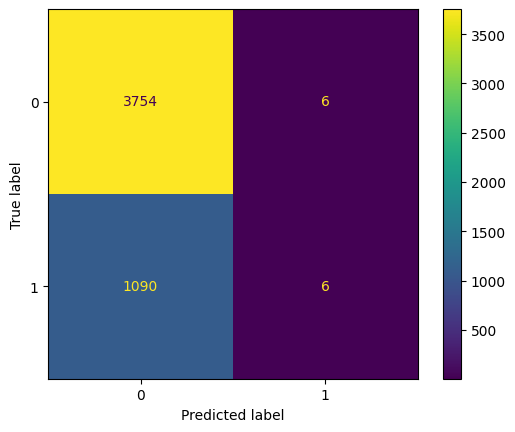

In [181]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

logreg=LogisticRegression()
y_pred=cross_val_predict(logreg, X,y,cv=5)
cm=confusion_matrix(y,y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()




In [182]:
accuracy=accuracy_score(y,y_pred)
precision=precision_score(y,y_pred)
recall=recall_score(y,y_pred)
f1=f1_score(y,y_pred)

print('Accuracy:',accuracy)
print('Precision:',precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.7742998352553542
Precision: 0.5
Recall: 0.005474452554744526
F1 Score: 0.010830324909747292
